# 04 - Preparación para Modelado

## Objetivo

Formalizar el problema predictivo, definir el target y documentar el conjunto inicial de variables candidatas para modelos de clasificación binaria.

## Actividades realizadas

- Carga del dataset limpio y enriquecido.
- Definición de la variable objetivo `es_grave_o_mortal`.
- Revisión del desbalance del target y riesgos de data leakage.
- Catalogación de features candidatas y análisis preliminar de relación con el target.

## Entradas

- `data/processed/siniestros_limpio_enriquecido.csv`.

## Salidas

- Definición documentada del problema de modelado.
- Catálogo de variables candidatas y tablas preliminares para selección de features.


# 04 - Preparacion para Modelado

Este notebook inicia la etapa de Machine Learning sin entrenar modelos todavia. El foco esta puesto en formular el problema predictivo, definir el target, analizar su distribucion, seleccionar features candidatas y revisar relaciones preliminares con el desenlace.

## Hipótesis principal

**Hipótesis:** Las caracteristicas de la victima y del contexto del siniestro permiten anticipar si el caso terminara siendo grave o mortal.

Esta hipótesis transforma el problema vial en un problema supervisado de clasificacion binaria. La unidad de análisis es cada victima registrada en el dataset procesado y el objetivo es estimar si el desenlace pertenece a una categoria de alta severidad.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "siniestros_limpio_enriquecido.csv"
TARGET = "es_grave_o_mortal"

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## Carga de datos


## Carga del dataset procesado

Se trabaja exclusivamente con la version limpia y enriquecida ubicada en `data/processed/`. No se lee ni se modifica el archivo original de `data/raw/` en esta etapa.

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"No se encontro {DATA_FILE}. Ejecute primero notebooks/02_preprocessing.ipynb."
    )

df = pd.read_csv(DATA_FILE, parse_dates=["fecha_siniestro"])

print(f"Dataset cargado desde: {DATA_FILE.resolve()}")
print(f"Shape: {df.shape}")
display(df.head())
display(df.dtypes.rename("tipo").to_frame())

Dataset cargado desde: C:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\data\processed\siniestros_limpio_enriquecido.csv
Shape: (62076, 14)


,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,gravedad_victima,rol_victima,edad_grupo,es_mortal,es_grave_o_mortal,vulnerabilidad_usuario,mes_siniestro,dia_semana_siniestro,trimestre_siniestro
0,2019-01-01,2019,MOTO,M,54.0,GRAVE,NaN,46_60,0,1,ALTA,1,1,1
1,2019-01-01,2019,NaN,F,1.0,LEVE,NaN,menor_18,0,0,DESCONOCIDA,1,1,1
2,2019-01-01,2019,NaN,F,21.0,LEVE,NaN,18_30,0,0,DESCONOCIDA,1,1,1
3,2019-01-01,2019,NaN,F,32.0,LEVE,NaN,31_45,0,0,DESCONOCIDA,1,1,1
4,2019-01-01,2019,NaN,F,33.0,LEVE,NaN,31_45,0,0,DESCONOCIDA,1,1,1


,tipo
fecha_siniestro,datetime64[ns]
anio_siniestro,int64
modo_desplazamiento_victima,object
sexo_victima,object
edad_victima,float64
gravedad_victima,object
rol_victima,object
edad_grupo,object
es_mortal,int64
es_grave_o_mortal,int64


## Transformaciones


## Definicion del problema predictivo y target

El target elegido es `es_grave_o_mortal`, una variable binaria donde `1` identifica víctimas con gravedad `GRAVE` o `MORTAL`, y `0` identifica casos `LEVE`.

Esta eleccion es preferible a `es_mortal` para una primera etapa de modelado porque presenta menor desbalance de clases. Ademas, tiene utilidad practica: anticipar casos graves o mortales permite orientar acciones de prevencion vial, priorizacion de recursos y análisis de factores de riesgo antes de enfocarse en un desenlace extremadamente infrecuente como la mortalidad.

In [3]:
if TARGET not in df.columns:
    raise KeyError(f"No se encontro el target esperado: {TARGET}")

target_counts = df[TARGET].value_counts().sort_index()
target_percentages = (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "clase": target_counts.index,
    "cantidad": target_counts.values,
    "porcentaje": target_percentages.values,
})

print(f"Cantidad de clases: {df[TARGET].nunique()}")
display(target_summary)

Cantidad de clases: 2


,clase,cantidad,porcentaje
0,0,58995,95.04
1,1,3081,4.96


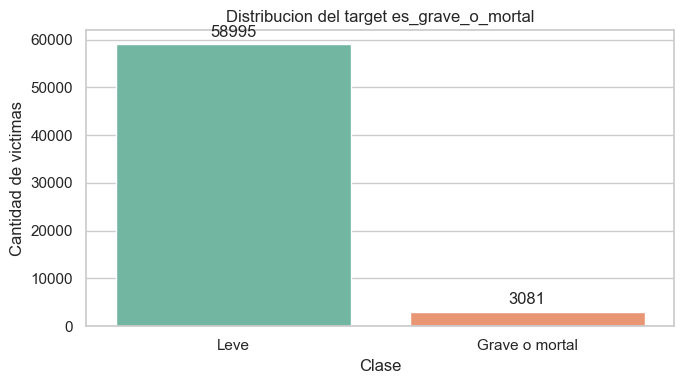

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x=TARGET, hue=TARGET, order=[0, 1], palette="Set2", legend=False, ax=ax)
ax.set_title("Distribucion del target es_grave_o_mortal")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de victimas")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Leve", "Grave o mortal"])

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

## Riesgos de data leakage

En un problema predictivo, las features deben representar informacion disponible antes o durante la evaluacion del siniestro, no informacion posterior que revele el desenlace. Por ese motivo se excluyen `gravedad_victima`, `GRAVEdad_victima`, `es_mortal`, `es_grave_o_mortal` como feature y cualquier variable derivada directamente del target. También se evita incorporar variables posteriores al evento, como fechas de fallecimiento, porque anticiparian informacion que no estaria disponible al momento de predecir.

In [5]:
excluded_features = [
    "GRAVEdad_victima",
    "gravedad_victima",
    "es_mortal",
    "es_grave_o_mortal",
    "fecha_fallecimiento_victima",
]

candidate_features = [
    "anio_siniestro",
    "modo_desplazamiento_victima",
    "sexo_victima",
    "edad_victima",
    "rol_victima",
    "edad_grupo",
    "vulnerabilidad_usuario",
    "mes_siniestro",
    "dia_semana_siniestro",
    "trimestre_siniestro",
]

candidate_features = [feature for feature in candidate_features if feature in df.columns]
missing_exclusions = [feature for feature in excluded_features if feature not in df.columns]

print("Features candidatas:")
display(pd.Series(candidate_features, name="feature").to_frame())

print("Variables excluidas por target/leakage o no disponibles en esta version:")
display(pd.DataFrame({"variable": excluded_features, "presente_en_df": [col in df.columns for col in excluded_features]}))

Features candidatas:


,feature
0,anio_siniestro
1,modo_desplazamiento_victima
2,sexo_victima
3,edad_victima
4,rol_victima
5,edad_grupo
6,vulnerabilidad_usuario
7,mes_siniestro
8,dia_semana_siniestro
9,trimestre_siniestro


Variables excluidas por target/leakage o no disponibles en esta version:


,variable,presente_en_df
0,GRAVEdad_victima,False
1,gravedad_victima,True
2,es_mortal,True
3,es_grave_o_mortal,True
4,fecha_fallecimiento_victima,False


## Ingeniería de características


## Tabla de features candidatas

La siguiente tabla documenta cada variable candidata, su tipo conceptual y la justificacion de uso. Esta seleccion todavia no implica entrenamiento: funciona como contrato inicial para la etapa siguiente.

In [6]:
feature_catalog = pd.DataFrame([
    {
        "feature": "anio_siniestro",
        "tipo": "temporal/numerica",
        "justificacion": "Captura cambios anuales en movilidad, registro y contexto vial.",
    },
    {
        "feature": "modo_desplazamiento_victima",
        "tipo": "categorica",
        "justificacion": "Representa el tipo de usuario vial y su exposicion relativa.",
    },
    {
        "feature": "sexo_victima",
        "tipo": "categorica",
        "justificacion": "Permite explorar diferencias demograficas en severidad registrada.",
    },
    {
        "feature": "edad_victima",
        "tipo": "numerica",
        "justificacion": "La edad puede asociarse con vulnerabilidad fisica y patrones de movilidad.",
    },
    {
        "feature": "rol_victima",
        "tipo": "categorica",
        "justificacion": "Describe la posicion de la victima en el hecho vial cuando esta disponible.",
    },
    {
        "feature": "edad_grupo",
        "tipo": "categorica ordinal",
        "justificacion": "Agrupa edades para capturar tramos de riesgo y reducir sensibilidad a valores extremos.",
    },
    {
        "feature": "vulnerabilidad_usuario",
        "tipo": "categorica derivada",
        "justificacion": "Resume conocimiento de dominio sobre usuarios con distinto nivel de proteccion vial.",
    },
    {
        "feature": "mes_siniestro",
        "tipo": "temporal/numerica",
        "justificacion": "Permite capturar estacionalidad mensual en ocurrencia y severidad.",
    },
    {
        "feature": "dia_semana_siniestro",
        "tipo": "temporal/numerica",
        "justificacion": "Distingue patrones semanales de movilidad y exposicion.",
    },
    {
        "feature": "trimestre_siniestro",
        "tipo": "temporal/numerica",
        "justificacion": "Agrega una lectura temporal menos granular que el mes.",
    },
])

feature_catalog = feature_catalog[feature_catalog["feature"].isin(candidate_features)].reset_index(drop=True)
display(feature_catalog)

,feature,tipo,justificacion
0,anio_siniestro,temporal/numerica,"Captura cambios anuales en movilidad, registro..."
1,modo_desplazamiento_victima,categorica,Representa el tipo de usuario vial y su exposi...
2,sexo_victima,categorica,Permite explorar diferencias demograficas en s...
3,edad_victima,numerica,La edad puede asociarse con vulnerabilidad fis...
4,rol_victima,categorica,Describe la posicion de la victima en el hecho...
5,edad_grupo,categorica ordinal,Agrupa edades para capturar tramos de riesgo y...
6,vulnerabilidad_usuario,categorica derivada,Resume conocimiento de dominio sobre usuarios ...
7,mes_siniestro,temporal/numerica,Permite capturar estacionalidad mensual en ocu...
8,dia_semana_siniestro,temporal/numerica,Distingue patrones semanales de movilidad y ex...
9,trimestre_siniestro,temporal/numerica,Agrega una lectura temporal menos granular que...


In [7]:
categorical_features = [
    feature for feature in candidate_features
    if df[feature].dtype == "object" or str(df[feature].dtype).startswith("category")
]

numeric_features = [
    feature for feature in candidate_features
    if pd.api.types.is_numeric_dtype(df[feature])
]

temporal_features = [
    feature for feature in candidate_features
    if feature in {"anio_siniestro", "mes_siniestro", "dia_semana_siniestro", "trimestre_siniestro"}
]

feature_groups = pd.DataFrame({
    "grupo": ["categoricas", "numericas", "temporales"],
    "variables": [categorical_features, numeric_features, temporal_features],
    "cantidad": [len(categorical_features), len(numeric_features), len(temporal_features)],
})

display(feature_groups)

,grupo,variables,cantidad
0,categoricas,"[modo_desplazamiento_victima, sexo_victima, ro...",5
1,numericas,"[anio_siniestro, edad_victima, mes_siniestro, ...",5
2,temporales,"[anio_siniestro, mes_siniestro, dia_semana_sin...",4


## Exploración inicial


## Relaciones preliminares con el target

Antes de entrenar modelos conviene revisar senales descriptivas: correlaciones simples para variables numericas y tasas de casos graves o mortales por categoria para variables categoricas. Estos análisis no prueban causalidad, pero ayudan a detectar variables informativas, problemas de codificacion y posibles sesgos.

,correlacion_con_target
edad_victima,0.033285
dia_semana_siniestro,0.028863
mes_siniestro,-0.013279
trimestre_siniestro,-0.013226
anio_siniestro,0.011882


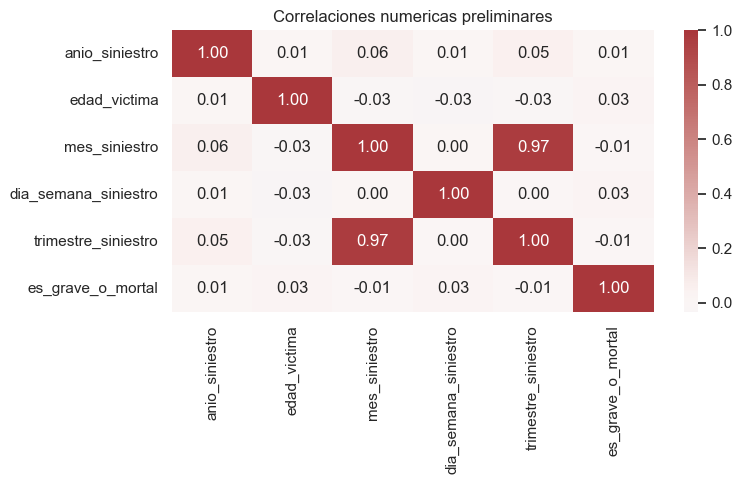

In [8]:
numeric_for_corr = [feature for feature in numeric_features if feature != TARGET]
corr_columns = numeric_for_corr + [TARGET]
correlation_matrix = df[corr_columns].corr(numeric_only=True)
target_correlations = (
    correlation_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("correlacion_con_target")
    .to_frame()
)

display(target_correlations)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlaciones numericas preliminares")
plt.tight_layout()
plt.show()

Relacion preliminar: modo_desplazamiento_victima vs es_grave_o_mortal


,cantidad,tasa_grave_o_mortal
modo_desplazamiento_victima,,
PEATON,6582,13.13
MOTO,17466,8.61
CAMION,184,7.07
AUTO,6204,5.05
MONOPATIN,159,5.03
BICICLETA,4964,4.71
UTILITARIO,652,4.60
OTRO,75,4.00
TAXI,597,2.51


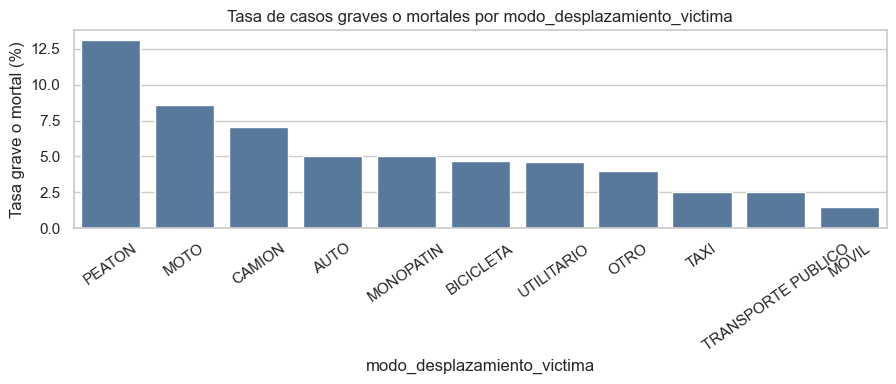

Relacion preliminar: sexo_victima vs es_grave_o_mortal


,cantidad,tasa_grave_o_mortal
sexo_victima,,
M,33666,6.70
F,17356,4.72
NaN,11054,0.06


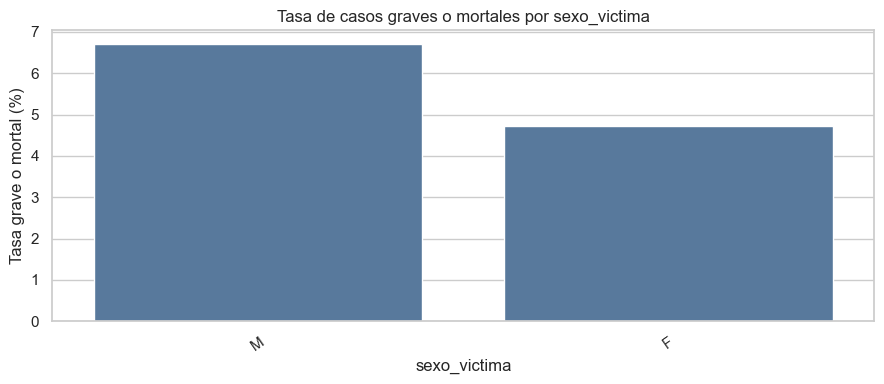

Relacion preliminar: rol_victima vs es_grave_o_mortal


,cantidad,tasa_grave_o_mortal
rol_victima,,
CONDUCTOR,268,100.00
PASAJERO,60,100.00
PEATON,6581,13.11
CICLISTA,4964,4.71
NaN,50203,3.30


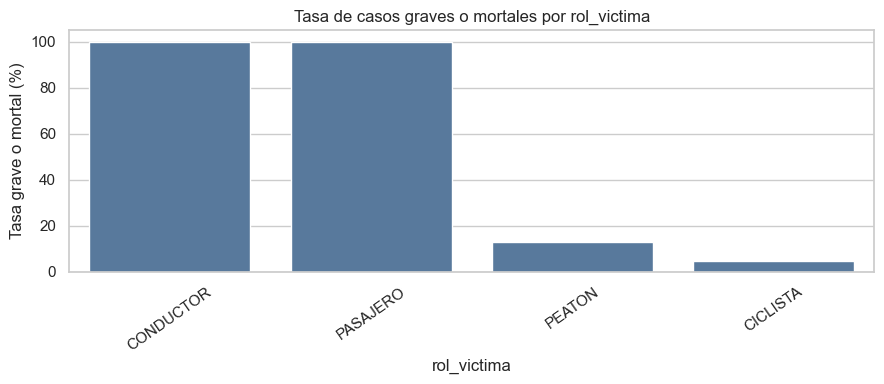

Relacion preliminar: edad_grupo vs es_grave_o_mortal


,cantidad,tasa_grave_o_mortal
edad_grupo,,
76_mas,1215,14.32
61_75,3195,7.54
menor_18,1884,7.11
46_60,7891,6.64
31_45,15882,6.38
18_30,15253,6.18
sin_dato,16756,0.31


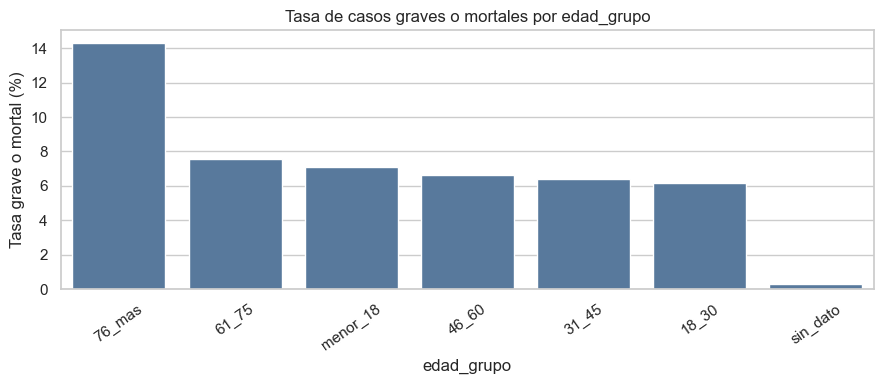

Relacion preliminar: vulnerabilidad_usuario vs es_grave_o_mortal


,cantidad,tasa_grave_o_mortal
vulnerabilidad_usuario,,
ALTA,29171,8.94
MEDIA,10550,4.21
DESCONOCIDA,22355,0.13


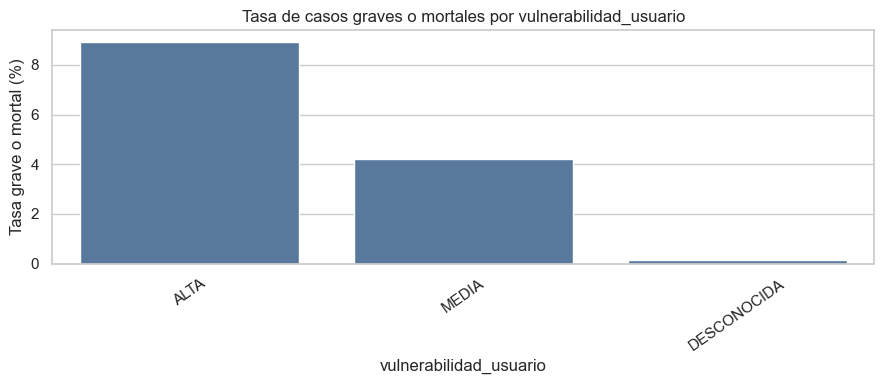

In [9]:
categorical_target_tables = {}

for feature in categorical_features:
    summary = (
        df.groupby(feature, dropna=False)[TARGET]
        .agg(cantidad="size", tasa_grave_o_mortal="mean")
        .sort_values("tasa_grave_o_mortal", ascending=False)
    )
    summary["tasa_grave_o_mortal"] = (summary["tasa_grave_o_mortal"] * 100).round(2)
    categorical_target_tables[feature] = summary
    print(f"Relacion preliminar: {feature} vs {TARGET}")
    display(summary)

    top_summary = summary.head(12).reset_index()
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(data=top_summary, x=feature, y="tasa_grave_o_mortal", color="#4C78A8", ax=ax)
    ax.set_title(f"Tasa de casos graves o mortales por {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Tasa grave o mortal (%)")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

## Cierre de preparacion

El notebook deja definido el problema de clasificacion binaria y una primera matriz conceptual de variables candidatas. La siguiente etapa deberia construir un pipeline de preprocesamiento para ML, decidir tratamiento de faltantes y encoding categorico, realizar `train_test_split` y recien entonces entrenar un modelo base.

# Conclusiones

Se formalizó el problema de clasificación binaria, se definió el target `es_grave_o_mortal` y se documentaron variables candidatas excluyendo atributos con riesgo de data leakage.

Esta notebook conecta el dataset enriquecido con la etapa de entrenamiento, dejando establecida la lógica conceptual del modelado sin entrenar modelos todavía.
